# WAV2HYP: Catalog comparer

Compare two **locator** H5 catalogs (Canonical vs Test): event rates, map overlay, origin offsets (polar), and shared-arrival timing.

**Y metric for arrival scatter:** EQT `peak_value` (canonical) is joined from **`eqt-volpick.h5`** when that file exists (`ctx.paths.eqt_volpick_h5`); the helper also uses **`peak_value_*` on the locator** if present. If neither is available, it falls back to NLL **`weight`** or **`residual`**, and axis labels follow automatically.

Edit `CONFIG`, then run top-to-bottom. Figures are **displayed** and **saved** under `notebooks/<volcano>/`.

In [1]:
from __future__ import annotations

from pathlib import Path

import yaml
from IPython.display import display

from wav2hyp.config_loader import config_path_anchor
from wav2hyp.viz import catalog_comparer as cc
from wav2hyp.viz.catalog_explorer_utils import load_notebook_context, print_context_summary
from wav2hyp.viz.notebook_styles import apply_notebook_style

apply_notebook_style()

## Setup

- `locator_h5_test`: set to an alternate `nll.h5`, or leave unset to use the default from the YAML (`output.base_dir` / `output.locator_dir` / `nll.h5`).
- `histogram_freq`: pandas offset string for the event-rate plot (e.g. `1h`).

In [ ]:
CONFIG = {
    "config_file": "examples_local/sthelens.yaml",
    "run_base_dir": None,
    "locator_h5_canonical": "/home/jwellik/PYTHON/PKG/wav2hyp/examples_local/stehelens_catalog_usgs.h5",
    "locator_h5_test": None,
    "label_canonical": "Canonical (USGS)",
    "label_test": "Test (wav2hyp)",
    "t1": "2004-09-23T00:00:00",
    "t2": "2004-09-24T00:00:00",
    "event_match_tolerance_s": 5.0,
    "histogram_freq": "1h",
}

In [3]:
CONFIG_FILE = CONFIG.get("config_file", "examples_local/sthelens.yaml")

_cwd = Path.cwd()
if (_cwd / CONFIG_FILE).is_file():
    CONFIG_PATH = (_cwd / CONFIG_FILE).resolve()
elif (_cwd.parent / CONFIG_FILE).is_file():
    CONFIG_PATH = (_cwd.parent / CONFIG_FILE).resolve()
else:
    CONFIG_PATH = (_cwd / CONFIG_FILE).resolve()

with open(CONFIG_PATH) as f:
    _YAML_CFG = yaml.safe_load(f)

if CONFIG.get("run_base_dir"):
    RUN_BASE_DIR = Path(CONFIG["run_base_dir"]).expanduser().resolve()
else:
    RUN_BASE_DIR = (config_path_anchor(CONFIG_PATH) / _YAML_CFG["output"]["base_dir"]).resolve()

_locator_sub = _YAML_CFG["output"].get("locator_dir", "locations")
_DEFAULT_NLL_H5 = (RUN_BASE_DIR / _locator_sub / "nll.h5").resolve()

LOCATOR_H5_CANONICAL = (
    Path(CONFIG["locator_h5_canonical"]).expanduser().resolve()
    if CONFIG.get("locator_h5_canonical")
    else _DEFAULT_NLL_H5
)
if not CONFIG.get("locator_h5_test"):
    LOCATOR_H5_TEST = _DEFAULT_NLL_H5
else:
    LOCATOR_H5_TEST = Path(CONFIG["locator_h5_test"]).expanduser().resolve()

LABEL_CANONICAL = str(CONFIG.get("label_canonical", "Canonical"))
LABEL_TEST = str(CONFIG.get("label_test", "Test"))
T1 = CONFIG.get("t1")
T2 = CONFIG.get("t2")
EVENT_MATCH_TOLERANCE_S = float(CONFIG.get("event_match_tolerance_s", 5.0))
HISTOGRAM_FREQ = str(CONFIG.get("histogram_freq", "1h"))

NOTEBOOK_OUT = cc.default_notebook_export_dir(CONFIG_PATH)
VOLCANO_SLUG = CONFIG_PATH.stem
NOTEBOOK_OUT.mkdir(parents=True, exist_ok=True)

ctx = load_notebook_context(
    config_path=CONFIG_PATH,
    volcano_slug=VOLCANO_SLUG,
    notebook_output_dir=NOTEBOOK_OUT,
    run_base_dir=CONFIG.get("run_base_dir"),
    locator_h5=LOCATOR_H5_CANONICAL,
)
print_context_summary(ctx)
print("NOTEBOOK_OUT          ", NOTEBOOK_OUT)
print("LOCATOR_H5_CANONICAL  ", LOCATOR_H5_CANONICAL, "exists:", LOCATOR_H5_CANONICAL.exists())
print("LOCATOR_H5_TEST      ", LOCATOR_H5_TEST, "exists:", LOCATOR_H5_TEST.exists())
print("T1/T2                ", T1, T2, "| histogram", HISTOGRAM_FREQ)


CONFIG_PATH           /home/jwellik/PYTHON/PKG/wav2hyp/examples_local/sthelens.yaml
VOLCANO_SLUG          sthelens
NOTEBOOK_OUTPUT_DIR   /home/jwellik/PYTHON/PKG/wav2hyp/notebooks/sthelens
RUN_BASE_DIR          /home/jwellik/PYTHON/PKG/wav2hyp/results_local/sthelens
ARTIFACTS_DIR         /home/jwellik/PYTHON/PKG/wav2hyp/notebooks/sthelens
CATALOG_MAP_PNG_NAME  sthelens_map.png
INVENTORY_PATH        /home/jwellik/PYTHON/PKG/wav2hyp/examples/sthelens_inventory_redpy.xml
LOCATOR_H5            /home/jwellik/PYTHON/PKG/wav2hyp/results_local/sthelens/3_locations/nll.h5 exists: True
Catalog/Day use VolcanoFigure (with event-rate overlay); Event view uses VolcanoFigure(ts_axis_type=None) plus waveform clipboard stack.
Run the Catalog cell to load catalog_df (time-filtered) and figures.
NOTEBOOK_OUT           /home/jwellik/PYTHON/PKG/wav2hyp/notebooks/sthelens
LOCATOR_H5_CANONICAL   /home/jwellik/PYTHON/PKG/wav2hyp/results_local/sthelens/3_locations/nll.h5 exists: True
LOCATOR_H5_TEST       /ho

In [4]:
catalog_canonical_df, arrivals_canonical_df = cc.load_locator_tables(
    LOCATOR_H5_CANONICAL, t1=T1, t2=T2
)
catalog_test_df, arrivals_test_df = cc.load_locator_tables(LOCATOR_H5_TEST, t1=T1, t2=T2)

print(f"{LABEL_CANONICAL}: events={len(catalog_canonical_df):,}, arrivals={len(arrivals_canonical_df):,}")
print(f"{LABEL_TEST}: events={len(catalog_test_df):,}, arrivals={len(arrivals_test_df):,}")
display(catalog_canonical_df.head(3))
display(catalog_test_df.head(3))

Canonical: events=249, arrivals=3,301
Test: events=249, arrivals=3,301


,event_id,origin_time,latitude,longitude,depth_km,x,y,z,mag,mag_type,residual_rms,n_picks,n_p_picks,n_s_picks,azimuthal_gap,creation_info,comments
0,smi:local/1e4279f2-fe64-4171-8d23-d9c207fc0a30,2004-09-23 00:12:10.823735+00:00,46.105752,-122.187474,4.680398,NaN,NaN,NaN,NaN,,0.035853,10,5,5,343.2860,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."
1,smi:local/6b2f4bb8-1c81-4709-a183-3fdb3d6bef86,2004-09-23 02:03:09.761947+00:00,46.205069,-122.183221,900.923000,NaN,NaN,NaN,NaN,,0.076490,16,8,8,80.0443,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."
2,smi:local/2b51922b-859c-4a21-9fe3-4517c6d08a4f,2004-09-23 06:09:30.855559+00:00,46.212722,-122.212786,-3.197798,NaN,NaN,NaN,NaN,,0.050917,10,5,5,242.0170,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."


,event_id,origin_time,latitude,longitude,depth_km,x,y,z,mag,mag_type,residual_rms,n_picks,n_p_picks,n_s_picks,azimuthal_gap,creation_info,comments
0,smi:local/1e4279f2-fe64-4171-8d23-d9c207fc0a30,2004-09-23 00:12:10.823735+00:00,46.105752,-122.187474,4.680398,NaN,NaN,NaN,NaN,,0.035853,10,5,5,343.2860,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."
1,smi:local/6b2f4bb8-1c81-4709-a183-3fdb3d6bef86,2004-09-23 02:03:09.761947+00:00,46.205069,-122.183221,900.923000,NaN,NaN,NaN,NaN,,0.076490,16,8,8,80.0443,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."
2,smi:local/2b51922b-859c-4a21-9fe3-4517c6d08a4f,2004-09-23 06:09:30.855559+00:00,46.212722,-122.212786,-3.197798,NaN,NaN,NaN,NaN,,0.050917,10,5,5,242.0170,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."


## Partitions: Canonical only, Test only, Both

Matching: nearest `origin_time` in window, then one-to-one de-duplication (see `cc.match_events_one_to_one`).

In [5]:
matched_pairs = cc.match_events_one_to_one(
    catalog_canonical_df,
    catalog_test_df,
    tolerance_s=EVENT_MATCH_TOLERANCE_S,
)
matched_loc = cc.enrich_matched_pairs_locations(
    matched_pairs, catalog_canonical_df, catalog_test_df
)
canonical_only_df, test_only_df, both_at_canonical_df = cc.partition_by_match(
    catalog_canonical_df, catalog_test_df, matched_pairs
)

print(
    f"matched pairs: {len(matched_pairs):,} | canonical-only: {len(canonical_only_df):,} | test-only: {len(test_only_df):,}"
)
display(matched_loc.head(8))

matched pairs: 249 | canonical-only: 0 | test-only: 0


,event_id_canonical,origin_time_canonical,event_id_test,origin_time_test,dt_s,absdt,latitude_canonical,longitude_canonical,depth_km_canonical,latitude_test,longitude_test,depth_km_test
0,smi:local/1e4279f2-fe64-4171-8d23-d9c207fc0a30,2004-09-23 00:12:10.823735+00:00,smi:local/1e4279f2-fe64-4171-8d23-d9c207fc0a30,2004-09-23 00:12:10.823735+00:00,0.0,0.0,46.105752,-122.187474,4.680398,46.105752,-122.187474,4.680398
1,smi:local/6b2f4bb8-1c81-4709-a183-3fdb3d6bef86,2004-09-23 02:03:09.761947+00:00,smi:local/6b2f4bb8-1c81-4709-a183-3fdb3d6bef86,2004-09-23 02:03:09.761947+00:00,0.0,0.0,46.205069,-122.183221,900.923000,46.205069,-122.183221,900.923000
2,smi:local/2b51922b-859c-4a21-9fe3-4517c6d08a4f,2004-09-23 06:09:30.855559+00:00,smi:local/2b51922b-859c-4a21-9fe3-4517c6d08a4f,2004-09-23 06:09:30.855559+00:00,0.0,0.0,46.212722,-122.212786,-3.197798,46.212722,-122.212786,-3.197798
3,smi:local/1879da44-f203-4c40-afbd-2689fd59318b,2004-09-23 06:35:41.639724+00:00,smi:local/1879da44-f203-4c40-afbd-2689fd59318b,2004-09-23 06:35:41.639724+00:00,0.0,0.0,46.261597,-121.982947,9.129261,46.261597,-121.982947,9.129261
4,smi:local/3460e82d-c283-48db-a12f-87763c34fe38,2004-09-23 07:38:22.398636+00:00,smi:local/3460e82d-c283-48db-a12f-87763c34fe38,2004-09-23 07:38:22.398636+00:00,0.0,0.0,46.207504,-122.172699,-685.014000,46.207504,-122.172699,-685.014000
5,smi:local/5589352e-bc9b-48d2-8301-f5bf0437c029,2004-09-23 09:02:37.657201+00:00,smi:local/5589352e-bc9b-48d2-8301-f5bf0437c029,2004-09-23 09:02:37.657201+00:00,0.0,0.0,46.198546,-122.174077,-4.531428,46.198546,-122.174077,-4.531428
6,smi:local/9f48dd06-967b-45be-8778-3050e65366d0,2004-09-23 09:05:21.343522+00:00,smi:local/9f48dd06-967b-45be-8778-3050e65366d0,2004-09-23 09:05:21.343522+00:00,0.0,0.0,46.350304,-122.324460,10.509233,46.350304,-122.324460,10.509233
7,smi:local/376d94ac-7e62-43a6-90d3-dbb896341e72,2004-09-23 09:07:45.749447+00:00,smi:local/376d94ac-7e62-43a6-90d3-dbb896341e72,2004-09-23 09:07:45.749447+00:00,0.0,0.0,46.194546,-122.192615,-1.606712,46.194546,-122.192615,-1.606712


In [6]:
shared_arrivals = cc.build_shared_arrivals(
    matched_pairs, arrivals_canonical_df, arrivals_test_df
)
# EQT peak_value for Y in scatter: join from eqt-volpick by station + P/S and nearest time
shared_arrivals = cc.enrich_shared_arrivals_with_eqt_peak_value(
    shared_arrivals,
    eqt_volpick_h5=ctx.paths.eqt_volpick_h5,
    t1=T1,
    t2=T2,
)
print(f"shared arrivals rows: {len(shared_arrivals):,}")
display(shared_arrivals.head(12))


shared arrivals rows: 3,301


,origin_time_canonical,trace_id_canonical,station_id_canonical,phase_canonical,pick_id_canonical,arrival_time_canonical,residual_canonical,weight_canonical,residual_uncert_canonical,weight_uncert_canonical,...,arrival_time_test,residual_test,weight_test,residual_uncert_test,weight_uncert_test,creation_info_test,comments_test,arrival_time_delta,arrival_id_canonical,arrival_id_test
0,2004-09-23 21:06:18.823830+00:00,.EDM..Z,.EDM,P,smi:local/1504c233-b127-4eaa-affc-dad7737006ea,2004-09-23 21:06:28.791000+00:00,1.2386,0.0000,NaN,NaN,...,2004-09-23 21:06:28.791000+00:00,1.2386,0.0000,NaN,NaN,{},[],0.0,smi:local/1504c233-b127-4eaa-affc-dad7737006ea,smi:local/1504c233-b127-4eaa-affc-dad7737006ea
1,2004-09-23 21:06:18.823830+00:00,.EDM..N,.EDM,S,smi:local/d9c4df82-69ac-4335-9524-afc5eded7ea4,2004-09-23 21:06:33.661000+00:00,-0.2633,1.1094,NaN,NaN,...,2004-09-23 21:06:33.661000+00:00,-0.2633,1.1094,NaN,NaN,{},[],0.0,smi:local/d9c4df82-69ac-4335-9524-afc5eded7ea4,smi:local/d9c4df82-69ac-4335-9524-afc5eded7ea4
2,2004-09-23 21:06:18.823830+00:00,.HSR..Z,.HSR,P,smi:local/e79179de-9ef6-4b4c-b56e-195367c64f96,2004-09-23 21:06:27.721000+00:00,-0.2702,1.0799,NaN,NaN,...,2004-09-23 21:06:27.721000+00:00,-0.2702,1.0799,NaN,NaN,{},[],0.0,smi:local/e79179de-9ef6-4b4c-b56e-195367c64f96,smi:local/e79179de-9ef6-4b4c-b56e-195367c64f96
3,2004-09-23 21:06:18.823830+00:00,.JUN..Z,.JUN,P,smi:local/76d7b6fd-ad70-48fc-a5a7-a1acf7a6073a,2004-09-23 21:06:28.211000+00:00,0.0109,1.3260,NaN,NaN,...,2004-09-23 21:06:28.211000+00:00,0.0109,1.3260,NaN,NaN,{},[],0.0,smi:local/76d7b6fd-ad70-48fc-a5a7-a1acf7a6073a,smi:local/76d7b6fd-ad70-48fc-a5a7-a1acf7a6073a
4,2004-09-23 21:06:18.823830+00:00,.JUN..N,.JUN,S,smi:local/ea477e1a-809b-4faa-b692-7e41453245db,2004-09-23 21:06:34.971000+00:00,-0.0737,1.3643,NaN,NaN,...,2004-09-23 21:06:34.971000+00:00,-0.0737,1.3643,NaN,NaN,{},[],0.0,smi:local/ea477e1a-809b-4faa-b692-7e41453245db,smi:local/ea477e1a-809b-4faa-b692-7e41453245db
5,2004-09-23 21:06:18.823830+00:00,.SHW..Z,.SHW,P,smi:local/e2840a71-046d-4fed-b979-7c2321214761,2004-09-23 21:06:27.571000+00:00,-0.2503,1.1524,NaN,NaN,...,2004-09-23 21:06:27.571000+00:00,-0.2503,1.1524,NaN,NaN,{},[],0.0,smi:local/e2840a71-046d-4fed-b979-7c2321214761,smi:local/e2840a71-046d-4fed-b979-7c2321214761
6,2004-09-23 21:06:18.823830+00:00,.SHW..N,.SHW,S,smi:local/d3ac37be-ccad-4953-a614-29b753b6ef6a,2004-09-23 21:06:34.331000+00:00,-0.0585,1.3673,NaN,NaN,...,2004-09-23 21:06:34.331000+00:00,-0.0585,1.3673,NaN,NaN,{},[],0.0,smi:local/d3ac37be-ccad-4953-a614-29b753b6ef6a,smi:local/d3ac37be-ccad-4953-a614-29b753b6ef6a
7,2004-09-23 21:06:18.823830+00:00,.SOS..Z,.SOS,P,smi:local/51994d41-7452-40cb-9805-4c3a99e0add6,2004-09-23 21:06:26.781000+00:00,0.0234,1.2851,NaN,NaN,...,2004-09-23 21:06:26.781000+00:00,0.0234,1.2851,NaN,NaN,{},[],0.0,smi:local/51994d41-7452-40cb-9805-4c3a99e0add6,smi:local/51994d41-7452-40cb-9805-4c3a99e0add6
8,2004-09-23 21:06:18.823830+00:00,.STD..Z,.STD,P,smi:local/c5837e25-5856-4cb5-8ef8-420f55066046,2004-09-23 21:06:26.221000+00:00,-0.8906,0.0004,NaN,NaN,...,2004-09-23 21:06:26.221000+00:00,-0.8906,0.0004,NaN,NaN,{},[],0.0,smi:local/c5837e25-5856-4cb5-8ef8-420f55066046,smi:local/c5837e25-5856-4cb5-8ef8-420f55066046
9,2004-09-23 21:06:18.823830+00:00,.STD..N,.STD,S,smi:local/f6de1f02-1245-415d-855a-8630ccc2a872,2004-09-23 21:06:33.151000+00:00,-0.0106,1.3152,NaN,NaN,...,2004-09-23 21:06:33.151000+00:00,-0.0106,1.3152,NaN,NaN,{},[],0.0,smi:local/f6de1f02-1245-415d-855a-8630ccc2a872,smi:local/f6de1f02-1245-415d-855a-8630ccc2a872


## Plots (inline + `notebooks/<volcano>/`)


/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/shapely/ops.py:259: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  shell = type(geom.exterior)(zip(*func(*zip(*geom.exterior.coords))))
/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/shapely/ops.py:259: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  shell = type(geom.exterior)(zip(*func(*zip(*geom.exterior.coords))))


Failed to add hillshade via PyGMT: Error loading GMT shared library at 'libgmt.so'.
libgmt.so: cannot open shared object file: No such file or directory
Continuing without hillshade...


/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)
/home/jwellik/PYTHON/PKG/vdapseisutils/vdapseisutils/core/maps/cross_section.py:300: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  return self.ax.scatter(x, depth, **kwargs)
/home/jwellik/PYTHON/PKG/vdapseisutils/vdapseisutils/core/maps/cross_section.py:300: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  return self.ax.scatter(x, depth, **kwargs)


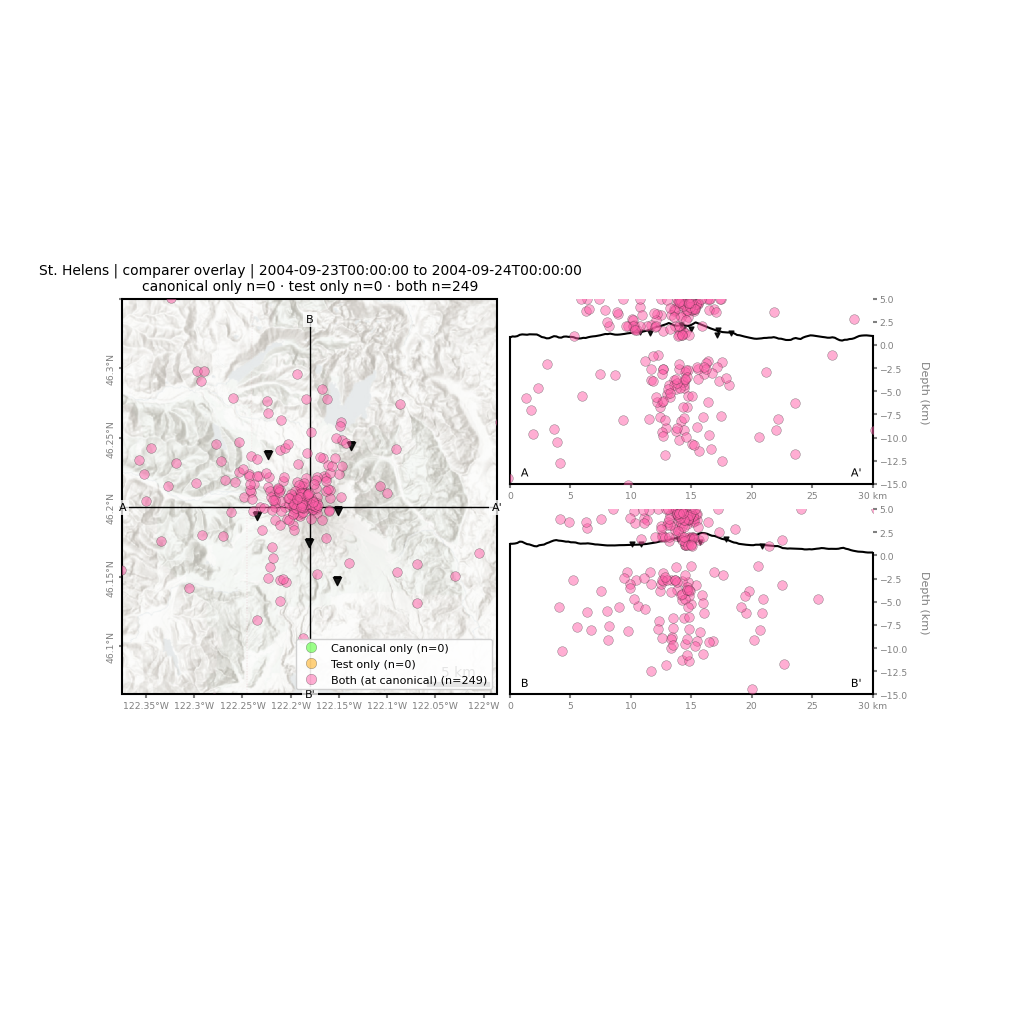

PosixPath('/home/jwellik/PYTHON/PKG/wav2hyp/notebooks/sthelens/catalog_comparer__volcano_overlay__sthelens.png')

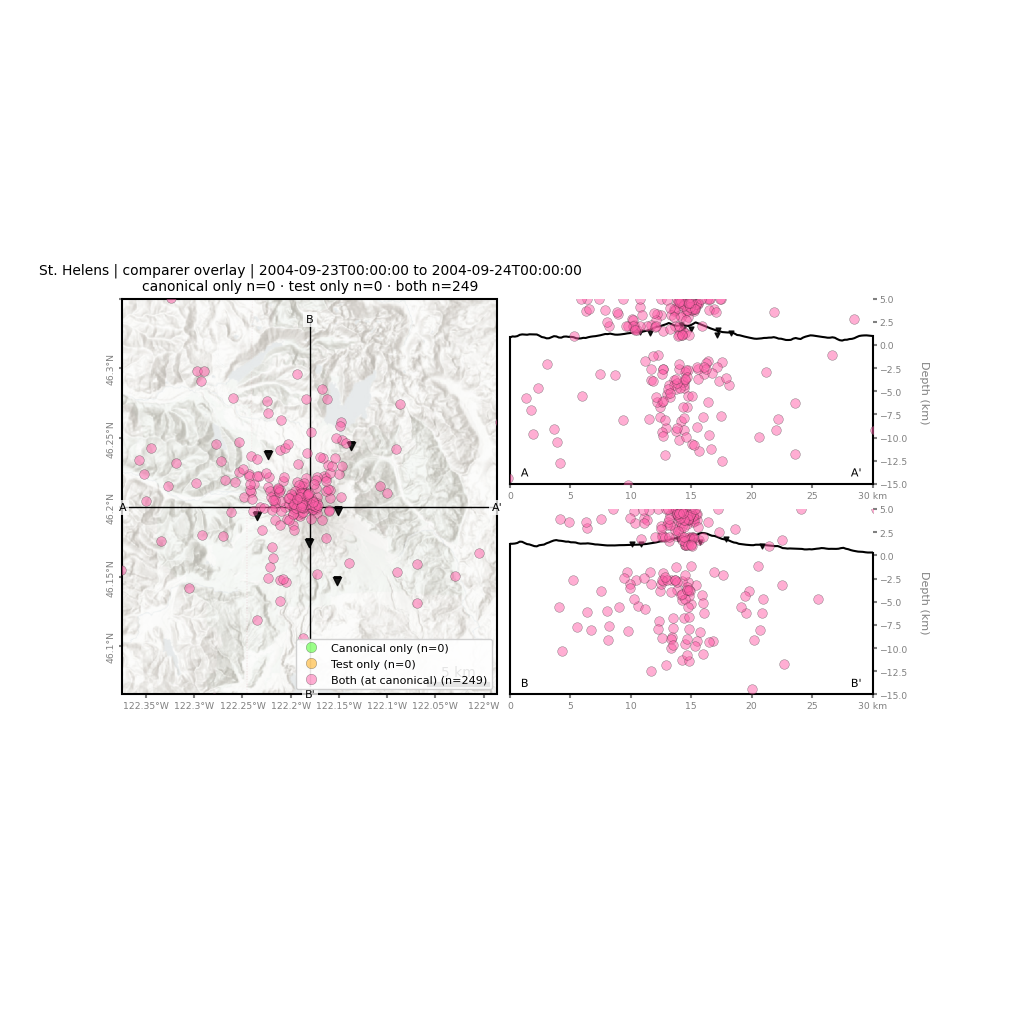

In [9]:
vfig = cc.make_catalog_comparer_volcano_figure(
    ctx.cfg,
    ctx.inventory_path,
    canonical_only_df,
    test_only_df,
    both_at_canonical_df,
    map_t1=str(T1) if T1 else None,
    map_t2=str(T2) if T2 else None,
)
display(vfig)
cc.save_figure(vfig, NOTEBOOK_OUT, cc.FIG_NAME_VOLCANO, volcano_slug=VOLCANO_SLUG)


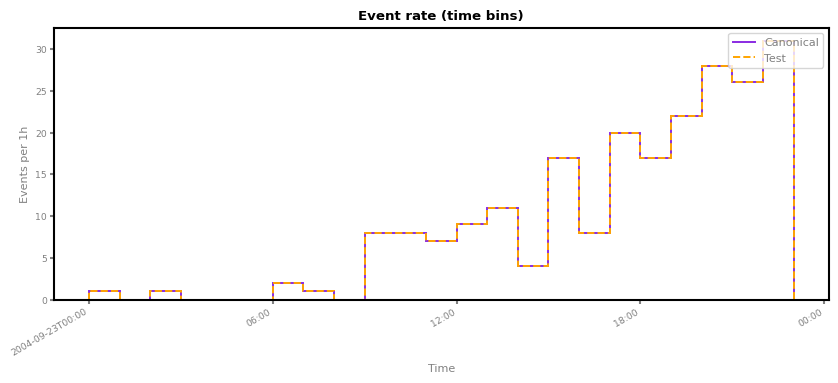

PosixPath('/home/jwellik/PYTHON/PKG/wav2hyp/notebooks/sthelens/catalog_comparer__timebin_event_rate__sthelens.png')

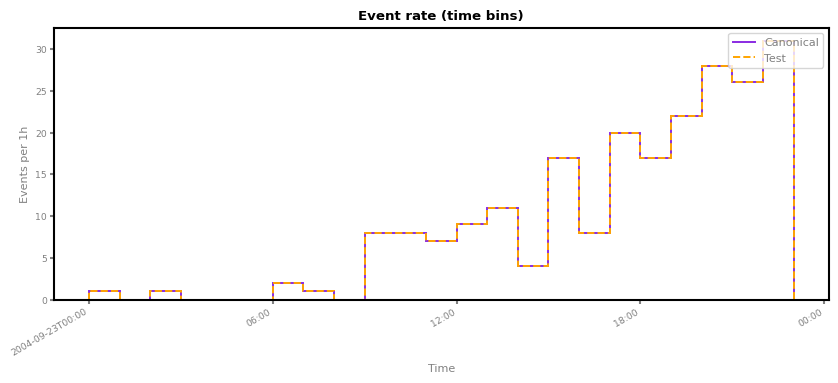

In [7]:
fig_rate = cc.plot_timebin_stairs(
    catalog_canonical_df,
    catalog_test_df,
    freq=HISTOGRAM_FREQ,
    label_canonical=LABEL_CANONICAL,
    label_test=LABEL_TEST,
)
display(fig_rate)
cc.save_figure(fig_rate, NOTEBOOK_OUT, cc.FIG_NAME_TIMEBIN, volcano_slug=VOLCANO_SLUG)


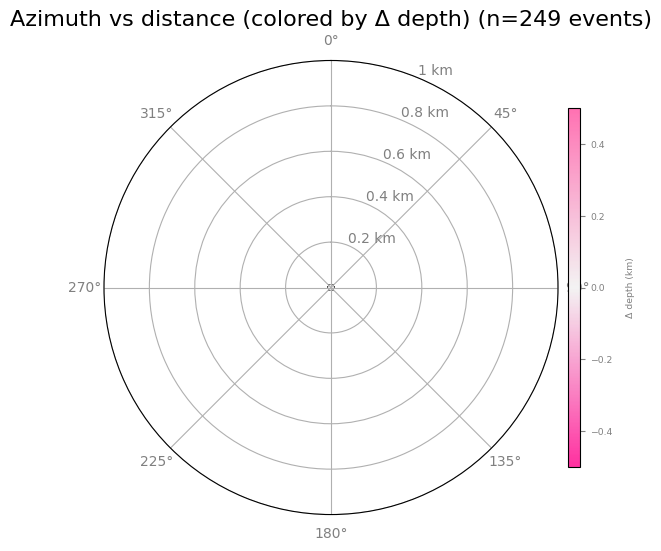

PosixPath('/home/jwellik/PYTHON/PKG/wav2hyp/notebooks/sthelens/catalog_comparer__polar_origin_offset__sthelens.png')

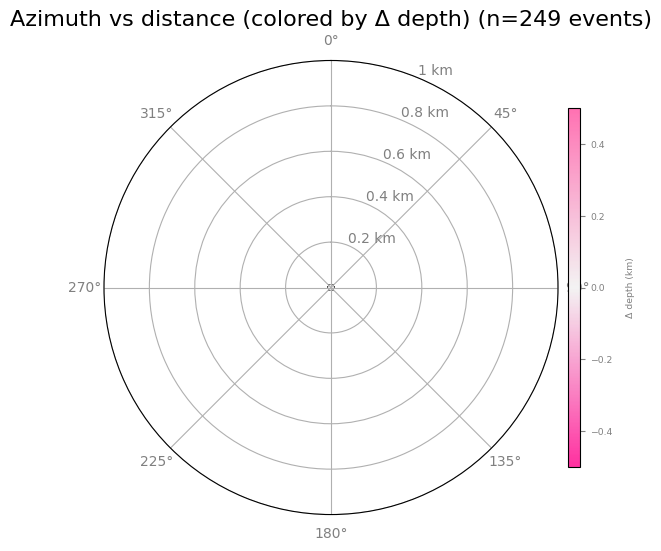

In [8]:
fig_pol = cc.plot_polar_origin_offset(matched_loc, title=None)
display(fig_pol)
cc.save_figure(fig_pol, NOTEBOOK_OUT, cc.FIG_NAME_POLAR, volcano_slug=VOLCANO_SLUG)


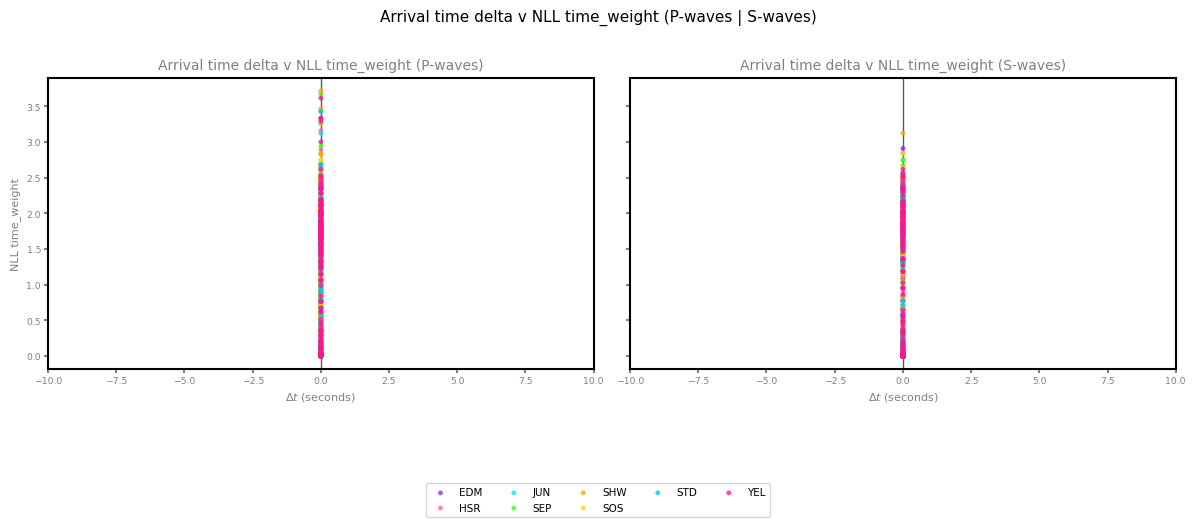

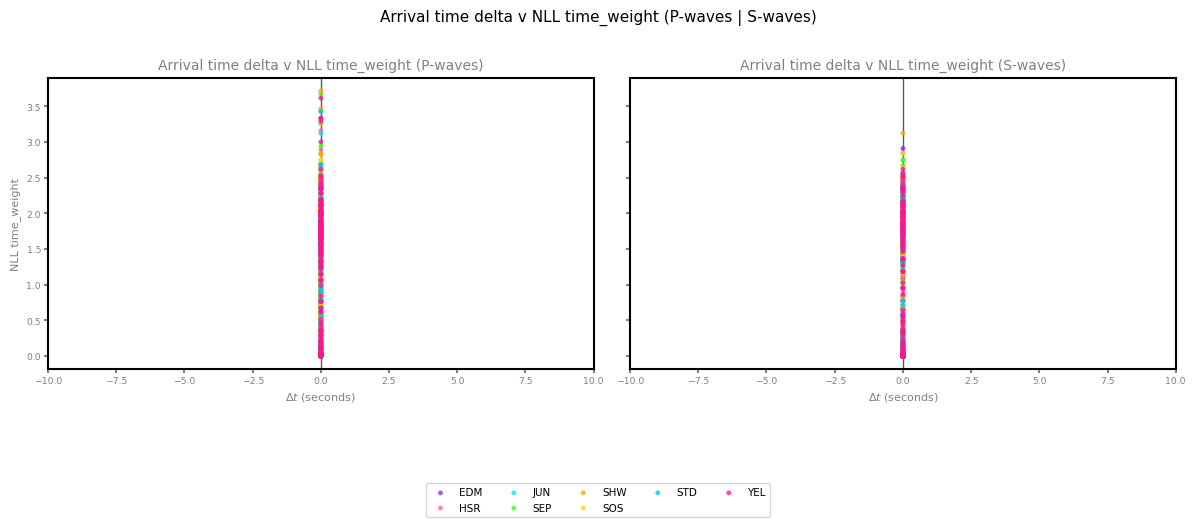

In [10]:
if len(shared_arrivals) == 0:
    print("no shared arrivals — skip arrival scatter / boxplot")
else:
    fig_s = cc.plot_arrival_scatter_p_s_panels(shared_arrivals)
    display(fig_s)
    cc.save_figure(fig_s, NOTEBOOK_OUT, cc.FIG_NAME_ARRIVAL_SCATTER, volcano_slug=VOLCANO_SLUG)


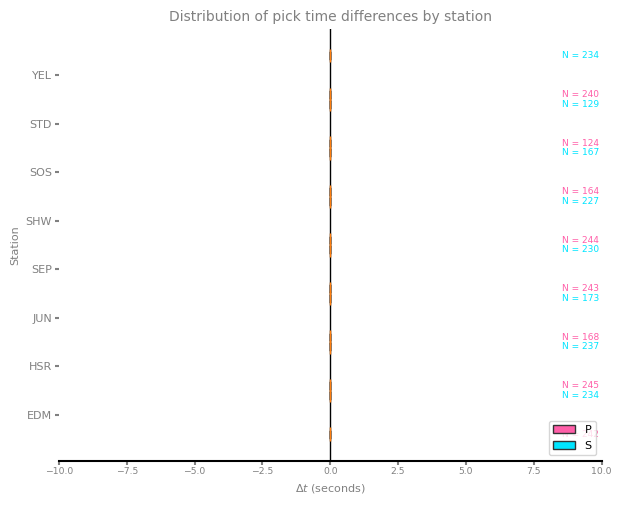

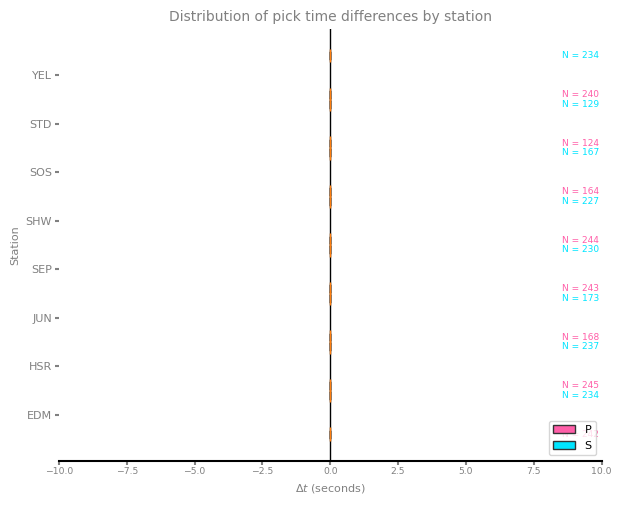

In [11]:
if len(shared_arrivals) == 0:
    pass
else:
    fig_b = cc.plot_arrival_boxplot_by_station(shared_arrivals)
    display(fig_b)
    cc.save_figure(fig_b, NOTEBOOK_OUT, cc.FIG_NAME_ARRIVAL_BOXPLOT, volcano_slug=VOLCANO_SLUG)
